**Implement an End to End CNN Model for Image Classification Task.**

Import Required Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.metrics import classification_report
import zipfile
import random

Task 1: Dataset Extraction & Visualization

In [ ]:
zip_path = "/content/drive/MyDrive/Datasets/FruitinAmazon.zip"
extract_path = "/content/FruitinAmazon"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP extracted successfully!")

ZIP extracted successfully!


In [ ]:
train_dir = "/content/FruitinAmazon/FruitinAmazon/train"

classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
print("Classes:", classes)

Classes: ['graviola', 'pupunha', 'acai', 'cupuacu', 'guarana', 'tucuma']


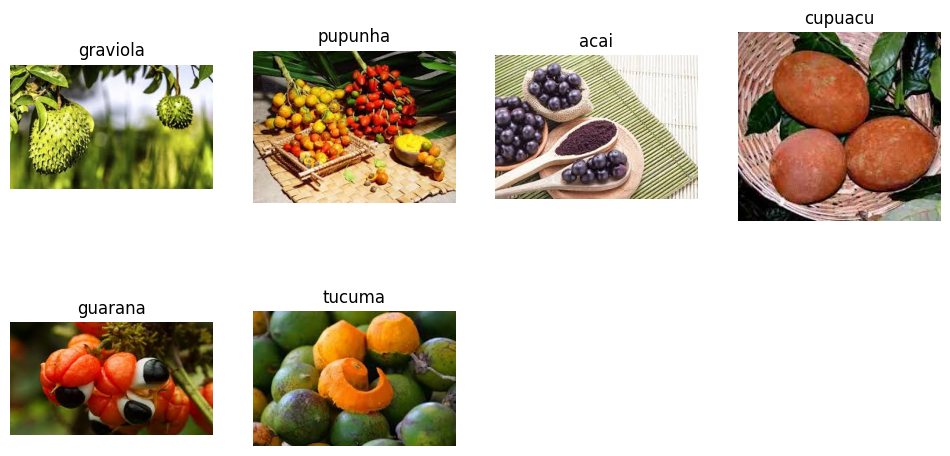

In [ ]:
plt.figure(figsize=(12,6))

for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, (len(classes)//2)+1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

Task 2: Load and Preprocess Dataset

In [ ]:
corrupted_images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            Image.open(img_path).verify()
        except:
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")
            corrupted_images.append(img_path)

if len(corrupted_images) == 0:
    print("No corrupted images found.")

No corrupted images found.


In [ ]:
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [ ]:
test_dir = "/content/FruitinAmazon/FruitinAmazon/test"

if os.path.exists(test_dir):
    test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        test_dir,
        labels='inferred',
        label_mode='int',
        image_size=(img_height, img_width),
        batch_size=batch_size,
        shuffle=False
    )
    test_ds = test_ds.map(lambda x, y: (rescale(x), y))
else:
    print("No test folder found, using validation data as test set.")
    test_ds = val_ds

Found 30 files belonging to 6 classes.


Task 3: Build CNN Model

In [ ]:
num_classes = len(classes)

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compile the Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Task 5: Train the Model

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

earlystop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    batch_size=16,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.1354 - loss: 1.9868

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 575ms/step - accuracy: 0.1250 - loss: 2.0803 - val_accuracy: 0.0000e+00 - val_loss: 2.2708
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.2859 - loss: 1.6821

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 490ms/step - accuracy: 0.2639 - loss: 1.7028 - val_accuracy: 0.8333 - val_loss: 1.3721
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 456ms/step - accuracy: 0.2500 - loss: 1.6781 - val_accuracy: 0.6111 - val_loss: 1.4473
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.5307 - loss: 1.4817

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 731ms/step - accuracy: 0.5139 - loss: 1.4818 - val_accuracy: 0.6111 - val_loss: 1.3635
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.5706 - loss: 1.2174

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 775ms/step - accuracy: 0.5556 - loss: 1.2144 - val_accuracy: 0.8333 - val_loss: 0.7402
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 430ms/step - accuracy: 0.6944 - loss: 1.0595 - val_accuracy: 0.7222 - val_loss: 1.2335
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.8368 - loss: 0.7678

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 459ms/step - accuracy: 0.7917 - loss: 0.7673 - val_accuracy: 0.9444 - val_loss: 0.4721
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 417ms/step - accuracy: 0.8056 - loss: 0.5839 - val_accuracy: 0.8333 - val_loss: 1.0038
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 427ms/step - accuracy: 0.9861 - loss: 0.3866 - val_accuracy: 0.8333 - val_loss: 0.4795
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 413ms/step - accuracy: 0.9861 - loss: 0.2323 - val_accuracy: 0.8333 - val_loss: 0.4764
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 1.0000 - loss: 0.1427

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 481ms/step - accuracy: 1.0000 - loss: 0.1319 - val_accuracy: 0.8333 - val_loss: 0.3612
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 781ms/step - accuracy: 1.0000 - loss: 0.0648 - val_accuracy: 0.8333 - val_loss: 0.4061
Epoch 13/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 1.0000 - loss: 0.0396

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 696ms/step - accuracy: 1.0000 - loss: 0.0432 - val_accuracy: 0.8333 - val_loss: 0.3312
Epoch 14/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 1.0000 - loss: 0.0252

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 455ms/step - accuracy: 1.0000 - loss: 0.0283 - val_accuracy: 0.9444 - val_loss: 0.2578
Epoch 15/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 406ms/step - accuracy: 1.0000 - loss: 0.0128 - val_accuracy: 0.8333 - val_loss: 0.3201
Epoch 16/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 422ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 0.8333 - val_loss: 0.4641
Epoch 17/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 430ms/step - accuracy: 1.0000 - loss: 0.0064 - val_accuracy: 0.8333 - val_loss: 0.4874
Epoch 18/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 419ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.8333 - val_loss: 0.4313
Epoch 19/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 409ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.8333 - val_loss: 0.4047
Epoch 20/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 482ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.8333 - val_loss: 0.3690


Task 6: Evaluate the Model

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.7333 - loss: 1.1455
Test Accuracy: 0.7333333492279053


Task 7: Save and Load the Model

In [ ]:
model.save("fruit_model.keras")

In [ ]:
loaded_model = tf.keras.models.load_model("fruit_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Task 8: Predictions & Classification Report

In [ ]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)

y_pred_probs = loaded_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step


In [ ]:
print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

    graviola       0.57      0.80      0.67         5
     pupunha       0.75      0.60      0.67         5
        acai       0.71      1.00      0.83         5
     cupuacu       0.80      0.80      0.80         5
     guarana       0.80      0.80      0.80         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.73        30
   macro avg       0.77      0.73      0.72        30
weighted avg       0.77      0.73      0.72        30



Task 9: Visualize Training History

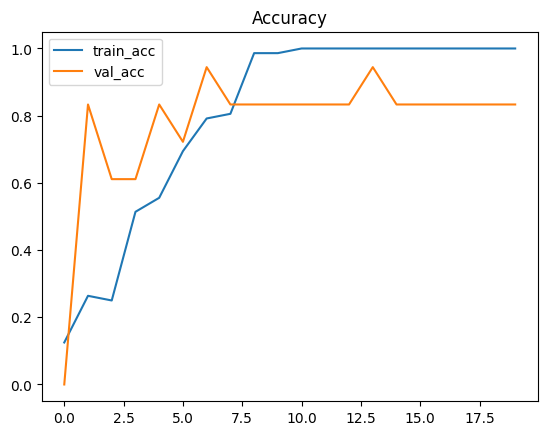

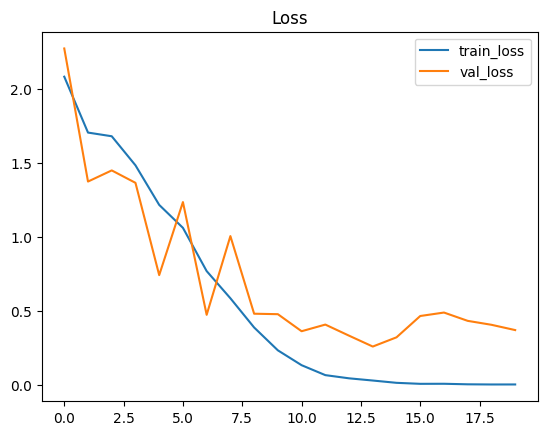

In [ ]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()